# Descriptive statistics about ESCO and O*NET skills and occupations
Felix Zaussinger | 06.04.2022

## Core Analysis Goal(s)
1. Find out how green & brown skills/tasks are distributed across occupations:
- What are the greenest/brownest occupations according to ESCO? Do they make any sense?
- What are the greenest occupations according to O*NET? How do they compare with
those in ESCO?
- How well do the greenness scores correlate?
- Does differentiating essential & optional ESCO skills make a big or marginal
difference?
2. What tasks/skills are important for the greennest/brownest occupations? How do
they compare between ESCO & O*NET?
3.

## Key Insight(s)
1.
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, stats_utils, plotting_utils
from src.data.framework import OccFramework
# import mapping_career_causeways

plt.style.use({'figure.facecolor': 'white'})

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
sns.set(rc={'figure.figsize': (5, 5.), 'figure.facecolor': 'white'})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths(fn_config_path="paths_config.yml")

Configuration files

In [2]:
fn_config_path = "paths_config.yml"
fn_config_data = "data_config.yml"
fn_config_model = "model_config.yml"
fn_config_vis = "vis_config.yml"

## 1. Inspection of ESCO data

In [44]:
of = OccFramework(fn_config_path=fn_config_path, fn_config_data=fn_config_data)

In [4]:
of.combine_occupation_metadata()

INFO:src.data.framework:Creating occupation-skills matrix.


C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco,gbn_classification_esco,onet_code,title_gtp,occupation_type,n_new_green_tasks_gtp,n_existing_green_tasks_gtp,n_non_green_tasks_gtp,share_green_gtp,title_vona2018,share_green_vona2018,total_spec_tasks_vona2018,green_spec_tasks_vona2018,id,concept_uri,preferred_label,onet_occupation,is_brown_onet,is_green_onet,is_neutral_onet,gbn_classification_onet
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",8,0,0.000000,0,0.0,8,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
1,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",39,0,0.000000,0,0.0,39,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
2,Occupation,http://data.europa.eu/esco/occupation/2f372afe...,2654,performance lighting director,television lighting supervisor\nTV lighting su...,NaN,released,2016-07-05T13:46:52Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Performance lighting directors determine what ...,2654.1.4,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",38,2,0.052632,0,0.0,36,0.947368,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
3,Occupation,http://data.europa.eu/esco/occupation/30b25ee4...,2654,animation director,animation process director\ncartoon animation ...,NaN,released,2021-03-31T15:31:28.501Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Animation directors supervise and recruit mult...,2654.1.1,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",41,0,0.000000,0,0.0,41,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
4,Occupation,http://data.europa.eu/esco/occupation/3b6bea7d...,2654,video and motion picture producer,video & motion picture producer\nmovie produce...,NaN,released,2017-01-17T13:58:37Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture producers supervise t...,2654.3.2,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",39,0,0.000000,0,0.0,39,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [5]:
of.crosswalk_onet_esco_mcc_full

,id,concept_uri,preferred_label,isco_level_4,onet_code,onet_occupation
0,0,http://data.europa.eu/esco/occupation/00030d09...,technical director,2166,27-1011.00,art directors
1,1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,8121,51-4021.00,"extruding and drawing machine setters, operato..."
2,2,http://data.europa.eu/esco/occupation/0019b951...,precision device inspector,7543,51-9061.00,"inspectors, testers, sorters, samplers, and we..."
3,3,http://data.europa.eu/esco/occupation/0022f466...,air traffic safety technician,3155,17-3023.01,electronics engineering technicians
4,4,http://data.europa.eu/esco/occupation/002da35b...,hospitality revenue manager,2431,13-1161.00,market research analysts and marketing special...
...,...,...,...,...,...,...
2937,2937,http://data.europa.eu/esco/occupation/ff656b3a...,demographer,2120,15-2041.00,statisticians
2938,2938,http://data.europa.eu/esco/occupation/ff8d4065...,sorter labourer,9612,51-9199.01,recycling and reclamation workers
2939,2939,http://data.europa.eu/esco/occupation/ffa4dd5d...,armoured car guard,5414,33-9032.00,security guards
2940,2940,http://data.europa.eu/esco/occupation/ffade2f4...,civil service administrative officer,2422,11-3011.00,administrative services managers


### 1.1 ESCO Skills Pillar

In [6]:
skills_data = of.skills_metadata
skills_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13891 entries, 0 to 13890
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   conceptType                  13891 non-null  object 
 1   conceptUri                   13891 non-null  object 
 2   skillType                    13890 non-null  object 
 3   reuseLevel                   13891 non-null  object 
 4   preferredLabel               13891 non-null  object 
 5   altLabels                    13257 non-null  object 
 6   hiddenLabels                 109 non-null    object 
 7   status                       13891 non-null  object 
 8   modifiedDate                 13891 non-null  object 
 9   scopeNote                    226 non-null    object 
 10  definition                   3 non-null      object 
 11  inScheme                     13891 non-null  object 
 12  description                  13891 non-null  object 
 13  broaderConceptUr

#### Green, brown and neutral skills

Select GBN skill classification version (Raw ESCO version vs. ETH version)

In [7]:
clsf = "esco"

skill_cols_nf = ["skill_green_{}", "skill_brown_{}", "skill_neutral_{}"]
skill_cols = [col.format(clsf) for col in skill_cols_nf]

skill_clsf_col = "skill_classification_{}".format(clsf)

Number and share of skills by GBN classification

In [8]:
n_skills_by_gbn = skills_data[skill_cols].sum().to_frame("n")
n_skills_by_gbn.loc[:, "share"] = n_skills_by_gbn / len(skills_data)
n_skills_by_gbn

,n,share
skill_green_esco,570,0.041034
skill_brown_esco,477,0.034339
skill_neutral_esco,12844,0.924627


#### Skill type
- knowledge: body of facts, principles theories and practices related to a
field/work/study
- skills: ability to apply knowledge to complete tasks
- competence: proven ability to use knowledge and skills

In [9]:
skills_data.skillType.unique()

array(['skill/competence', 'knowledge', nan], dtype=object)

Q1: How are g/b/n skills distributed across skill types?

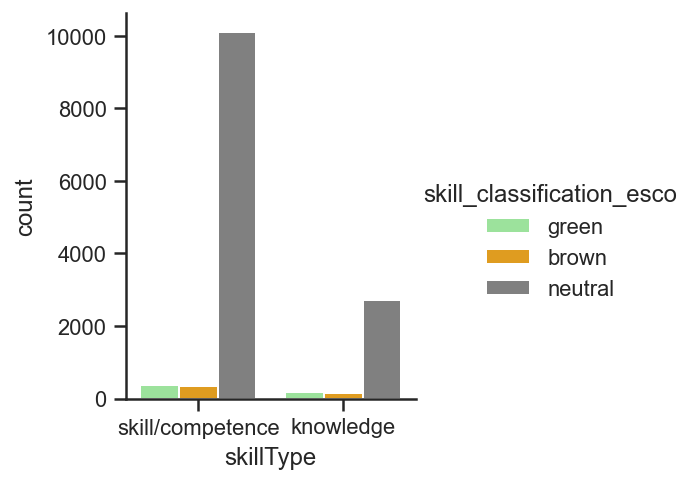

In [10]:
sns.catplot(
    data=skills_data,
    kind="count",
    x="skillType",
    hue=skill_clsf_col,
    height=3.5,
    hue_order=["green", "brown", "neutral"],
    palette=["lightgreen", "orange", "grey"],
)

plt.show()

In [11]:
skills_data.groupby("skillType")[skill_cols].sum()

,skill_green_esco,skill_brown_esco,skill_neutral_esco
skillType,,,
knowledge,186,141,2730
skill/competence,384,336,10113


#### Reuse level

The ESCO reuse level can be used to derive:
- how transversal a skill is
- a rough differentiation between skills and tasks

Skills probably correspond to cross-sector & transversal and tasks to sector-specific
and occupation-specific.

In [12]:
skills_data.reuseLevel.unique()

array(['sector-specific', 'occupation-specific', 'cross-sector',
       'transversal'], dtype=object)

Q: How are g/b/n skills distributed across reuse levels?

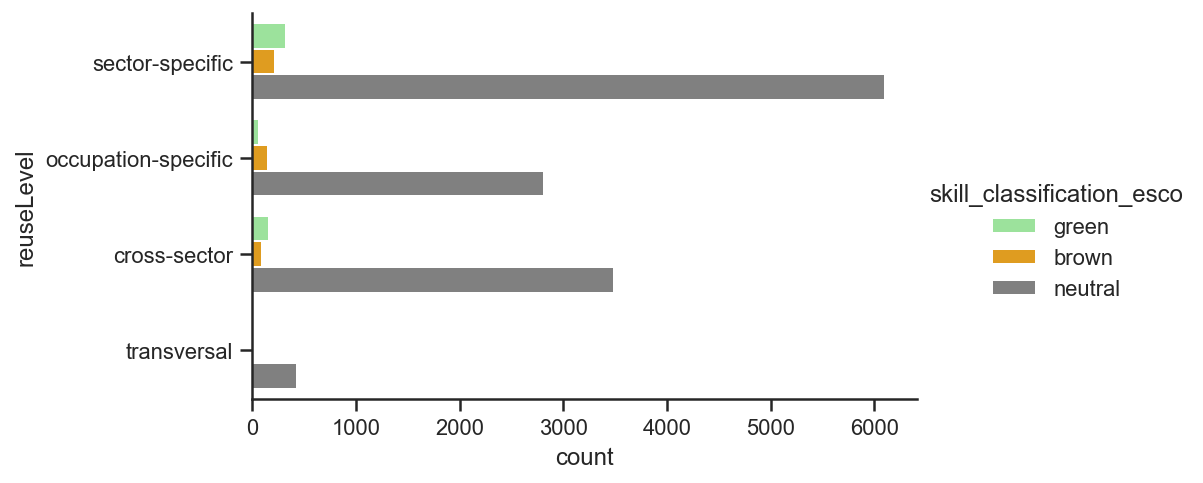

In [13]:
sns.catplot(
    data=skills_data,
    kind="count",
    y="reuseLevel",
    hue=skill_clsf_col,
    height=3.5,
    aspect=2,
    hue_order=["green", "brown", "neutral"],
    palette=["lightgreen", "orange", "grey"],
    orient="v"
)

Answer: green skills may be more transversal and thus enable smoother job
transitions.
- green skills more sector-specific and cross-sectoral
- brown skills more occupation-specific

Q: Are green skills more central/core than brown or neutral skills?

In [14]:
# drop nans
skills_data_clean = skills_data.dropna(subset=["coreness"])
len(skills_data_clean)

13379

In [15]:
df_pbsr = stats_utils.pbsr(skills_data_clean, "coreness", skill_cols)
df_pbsr

,pbsr,pval
skill_green_esco,0.052720,1.049824e-09
skill_brown_esco,-0.042455,8.996940e-07
skill_neutral_esco,-0.005557,5.204347e-01


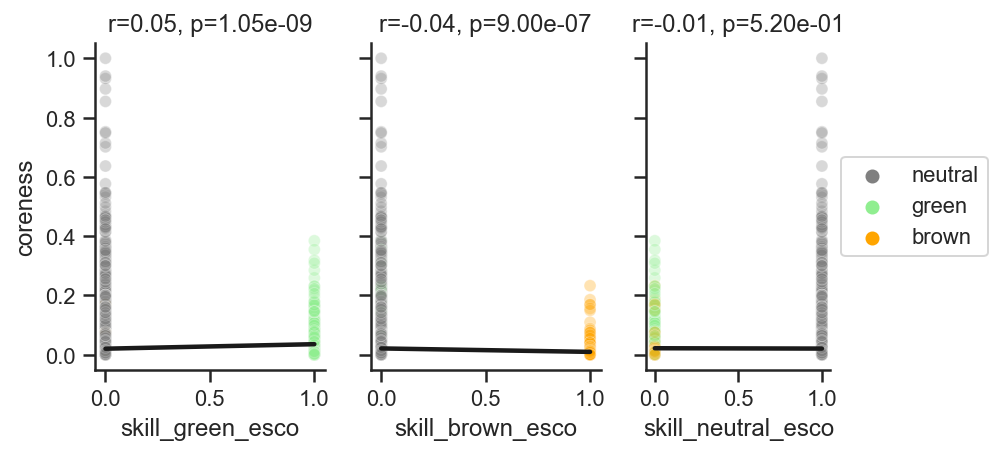

In [16]:
f, axes = plt.subplots(1, 3, sharey=True, sharex=True, figsize=(7, 3))

for i, xvar in enumerate(skill_cols):

    pbsr = df_pbsr.loc[xvar, :]
    r = pbsr.loc["pbsr"]
    pval = pbsr.loc["pval"]

    sns.scatterplot(
        data=skills_data_clean,
        x=xvar,
        y="coreness",
        hue=skill_clsf_col,
        hue_order=["neutral", "green", "brown"],
        palette=["grey", "lightgreen", "orange"],
        alpha=0.3,
        ax=axes[i],
        legend=True if i == len(skill_cols) - 1 else False
    )

    sns.regplot(
        data=skills_data_clean,
        x=xvar,
        y="coreness",
        scatter=False,
        color="k",
        ax=axes[i],
    )

    axes[i].set_title("r={:.2f}, p={:.2e}".format(r, pval))

    if i == len(skill_cols) - 1:
        plotting_utils.move_legend_to_right(axes[i])

sns.despine()

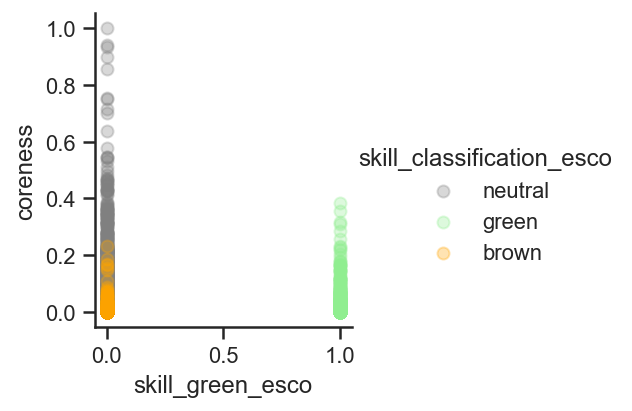

In [17]:
sns.lmplot(
    data=skills_data_clean,
    x="skill_green_{}".format(clsf),
    y="coreness",
    hue=skill_clsf_col,
    fit_reg=True,
    ci=None,
    hue_order=["neutral", "green", "brown"],
    palette=["grey", "lightgreen", "orange"],
    height=3,
    scatter_kws={"alpha": 0.3}
)

A: Green skills are more central/core than brown skills.

- *green* skills are weakly yet significantly *positively* correlated with skills
coreness
- *brown* skills are weakly yet significantly *negatively* correlated with skills
coreness
- *neutral* skills are *not significantly correlated* with skills coreness at p < 0.05

### 1.2 ESCO Occupations Pillar

Read matched occupation metadata

In [18]:
occ_data = of.occupation_metadata

Read occupation-skills and occupation-similarity matrices

In [19]:
osms = of.occupation_skills_matrix()
osm_weighted = osms["osm_weighted"]
osm_unweighted = osms["osm_unweighted"]

INFO:src.data.framework:Creating occupation-skills matrix.


**Q: What are the greenest/brownest occupations according to the ESCO GBN labels?**

In [20]:
occ_share_cols = ["share_green_{}".format(clsf), "share_brown_{}".format(clsf), "share_neutral_{}".format(clsf)]
occ_share_cols

['share_green_esco', 'share_brown_esco', 'share_neutral_esco']

Inspect occupations

In [21]:
keep_cols = [
    "preferredLabel", occ_share_cols[0], occ_share_cols[1], occ_share_cols[2],
    "conceptUri", "description"
]

(occ_data
.sort_values(occ_share_cols[1], ascending=False)
.loc[:, keep_cols])

,preferredLabel,share_green_esco,share_brown_esco,share_neutral_esco,conceptUri,description
1005,precast moulder,0.000000,0.550000,0.450000,http://data.europa.eu/esco/occupation/8d3fd879...,Precast moulders handcast decorative and struc...
947,tracer powder blender,0.076923,0.538462,0.384615,http://data.europa.eu/esco/occupation/ee37a4a5...,Tracer powder blenders operate machines and eq...
1006,electrolytic cell maker,0.000000,0.421053,0.578947,http://data.europa.eu/esco/occupation/8fdce434...,"Electrolytic cell makers create, finish and te..."
1061,V-belt builder,0.000000,0.411765,0.588235,http://data.europa.eu/esco/occupation/8edc768c...,V-belt builders form V-belts out of calendered...
1091,tunnel kiln operator,0.066667,0.400000,0.533333,http://data.europa.eu/esco/occupation/2ecbed9c...,Tunnel kiln operators control preheating chamb...
...,...,...,...,...,...,...
993,knitting machine supervisor,0.000000,0.000000,1.000000,http://data.europa.eu/esco/occupation/ab104661...,Knitting machine supervisors supervise the kni...
998,tanner,0.040000,0.000000,0.960000,http://data.europa.eu/esco/occupation/1ce76c3b...,Tanners program and use tannery drums. They pe...
1000,leather production machine operator,0.058824,0.000000,0.941176,http://data.europa.eu/esco/occupation/3da8ee8c...,Leather production machine operators use the t...
1001,leather finishing operator,0.040000,0.000000,0.960000,http://data.europa.eu/esco/occupation/7d99ed04...,Leather finishing operators use machines for f...


Share of 100% neutral occupations

In [22]:
(len(occ_data.query("share_neutral_{} == 1".format(clsf))) / len(occ_data)) * 100

44.08244680851064

In [23]:
occ_data_long = occ_data.melt(
    id_vars=['preferredLabel'],
    value_vars=occ_share_cols,
    var_name=skill_clsf_col,
    value_name="skill_share"

)
occ_data_long[skill_clsf_col] = \
    occ_data_long[skill_clsf_col].str.split("_", expand=True)[1]

In [24]:
occ_data_long.sort_values("preferredLabel")

,preferredLabel,skill_classification_esco,skill_share
8286,food service worker,neutral,0.933333
2270,food service worker,green,0.066667
5278,food service worker,brown,0.000000
3524,3D animator,brown,0.000000
6532,3D animator,neutral,1.000000
...,...,...,...
5366,zookeeper,brown,0.000000
2358,zookeeper,green,0.181818
1844,zoology technician,green,0.166667
7860,zoology technician,neutral,0.833333


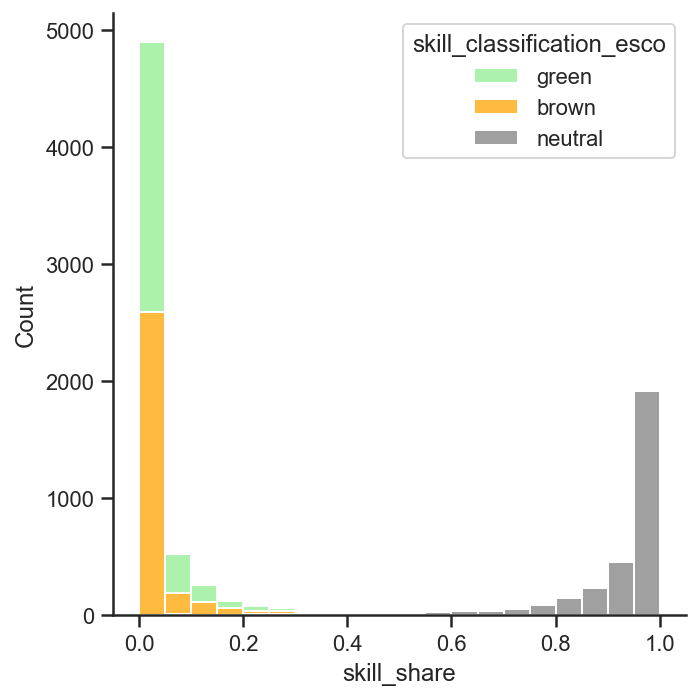

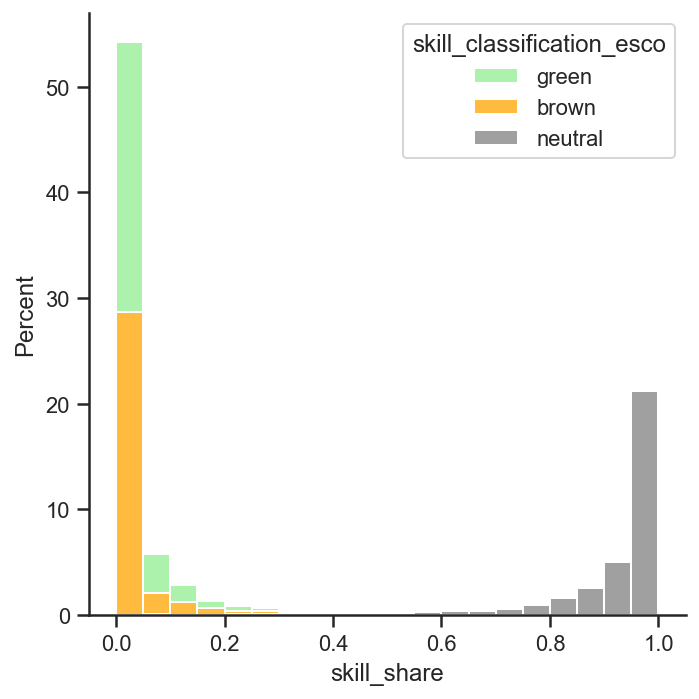

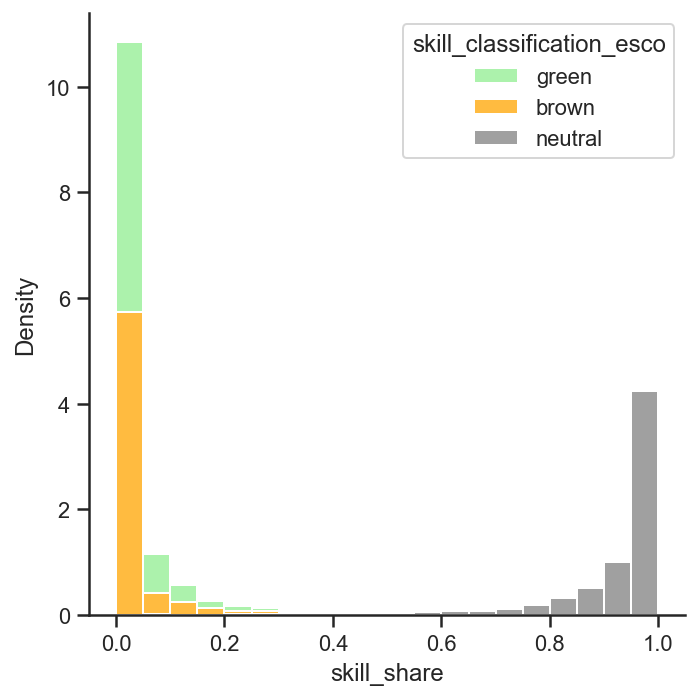

In [25]:
for stat in ["count", "percent", "density"]:
    f, ax = plt.subplots()

    sns.histplot(
        data=occ_data_long,
        # x="preferredLabel",
        x="skill_share",
        hue=skill_clsf_col,
        multiple="stack",
        binwidth=0.05,
        stat=stat,
        hue_order=["green", "brown", "neutral"],
        palette=["lightgreen", "orange", "grey"],
        ax=ax
    )

    sns.despine()
    plt.tight_layout()

Plot occupations with highest g/b/n skill shares.

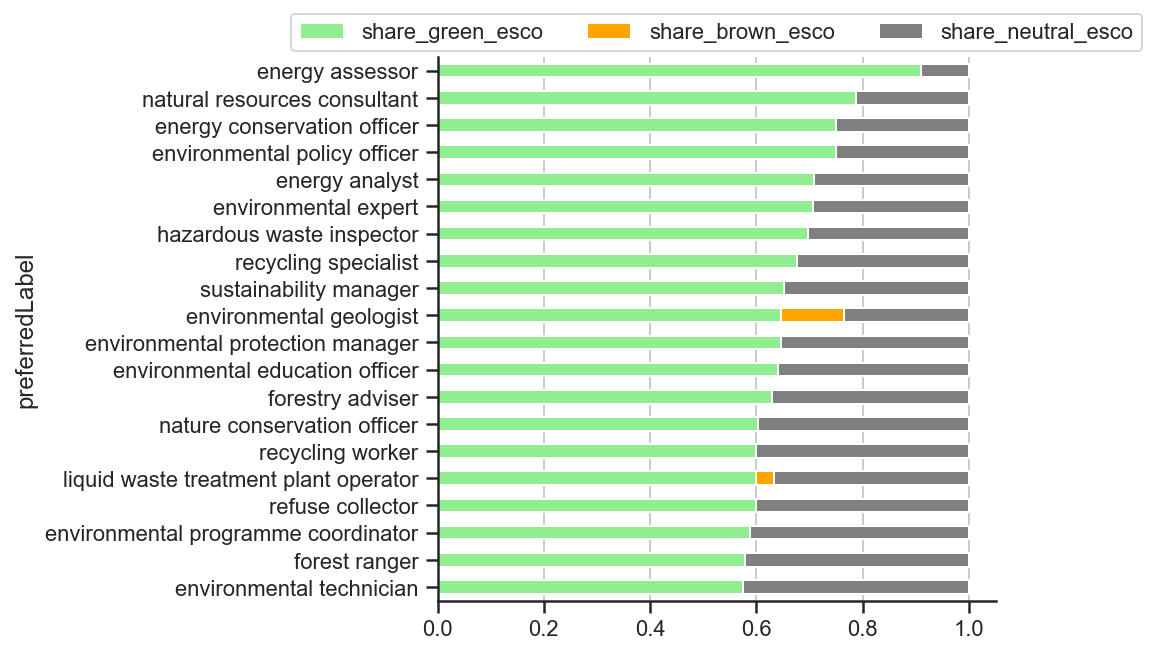

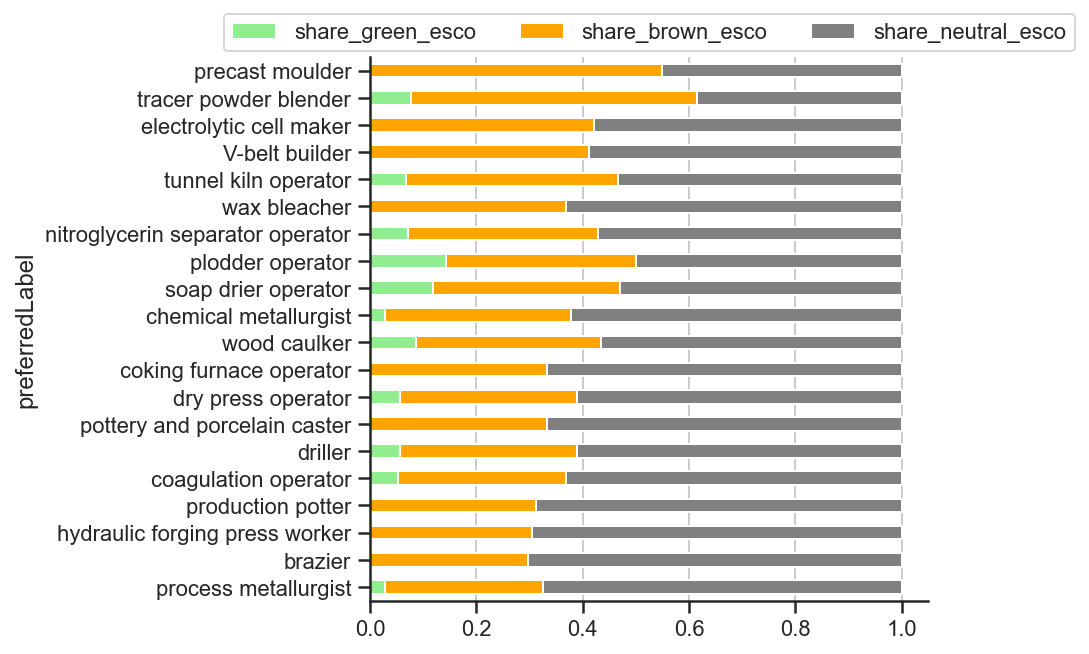

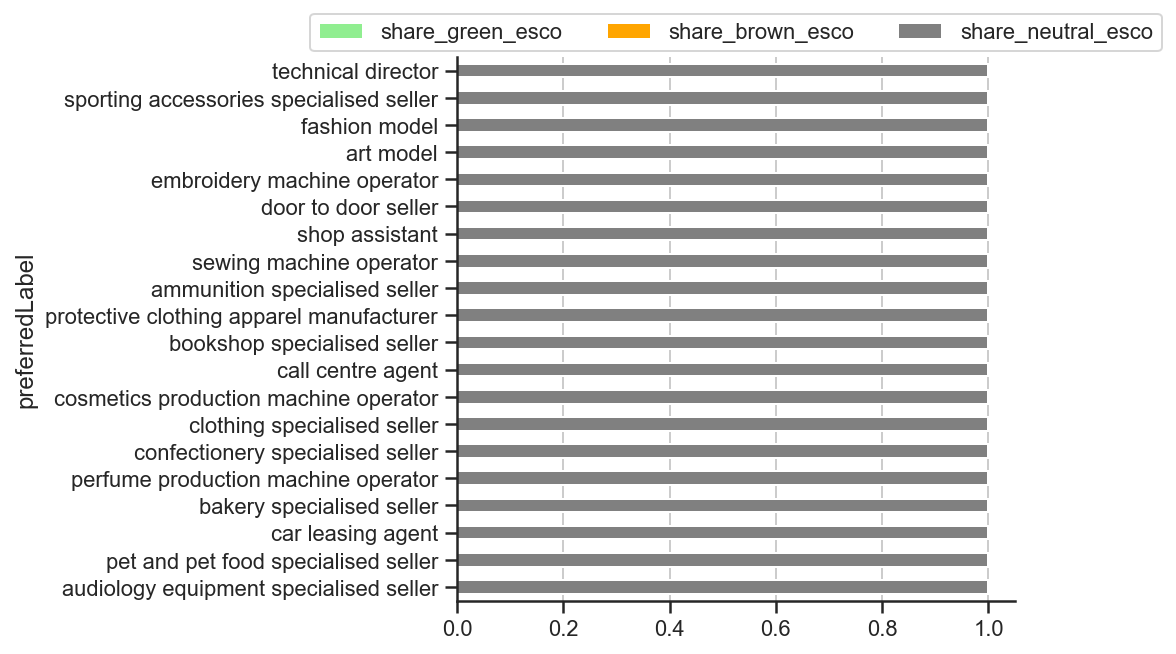

In [26]:
plotting_cols = occ_share_cols
n_highest = 20

for sorting_col in plotting_cols:
    occ_data_sub = (occ_data
                    .sort_values(sorting_col, ascending=False)
                    .loc[:, keep_cols]
                    .head(n_highest)[::-1])

    ax = occ_data_sub.plot.barh(
        stacked=True,
        x="preferredLabel",
        color=["lightgreen", "orange", "grey"]
    )

    ax.grid(axis="x", linestyle="-")
    plotting_utils.move_legend_to_top(ax, scale=1, ncol=3)
    sns.despine()

**Q: Which skills are mapped to the top-ranked occupations by GBN type?**

Join skills metadata (GBN classification etc) on occupation-skills mapping

In [27]:
cols_to_use = of.skills_metadata.columns.difference(of.occupations_to_skills.columns)

occ_skills_mapping_smd_merged = pd.merge(
    left=of.occupations_to_skills,
    right=of.skills_metadata[cols_to_use],
    left_on="skillUri",
    right_on="conceptUri",
    how="left"
)

Join skills metadata to occupation metadata on a many to one basis

In [28]:
occ_skills_mapping_all_merged = pd.merge(
    left=occ_skills_mapping_smd_merged,
    right=occ_data,
    left_on="occupationUri",
    right_on="conceptUri",
    how="left",
    suffixes=("_skills", "_occs")
)

Select example occupations for GBN separately

In [29]:
# n occ for ranking
n_occs = 10

# col names
occ_col = "preferredLabel_occs"
skill_col = "preferredLabel_skills"

for sorting_col in plotting_cols:
    # cols to keep in table
    keep_cols = [
        occ_col, skill_col, "relationType", skill_clsf_col,
        "skillType", "reuseLevel", "description_skills",
        sorting_col, "share_green_gtp", "gbn_classification_onet"
    ]

    # get n highest ranking occupations
    occ_ranking = occ_skills_mapping_all_merged.sort_values(
        sorting_col, ascending=False
    ).loc[:, occ_col].unique()
    occ_sel = occ_ranking[:n_occs].tolist()

    # sort and prepare output
    df_out = (occ_skills_mapping_all_merged
     .sort_values(
        by=[sorting_col, occ_col, "relationType", skill_clsf_col],
        ascending=[False, True, True, True]
    ).loc[occ_skills_mapping_all_merged[occ_col].isin(occ_sel), keep_cols]
     .set_index([occ_col, skill_col])
     )

    # store as csv
    df_out.to_csv(
        os.path.join(
            useful_paths.results_dir,
            "validation",
            "gbn_skills_classification",
            "occ_skills_mapping_by_{}_top_{}.csv".format(sorting_col, n_occs)
        ),
        sep=";"
    )

### Comparison of skills and tasks for a small selection (n=5) of green and brown occupations
- selection of occupations with high projected labour demand
- pinpointing them in ONET and ESCO respectively
- examining there tasks and skills (plus metadata)
- getting a qualitative understanding if these different perspectives correspond to each other!

In [30]:
search = of.occupation_metadata.preferredLabel.str.contains("battery")
of.occupation_metadata.loc[search]

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco,gbn_classification_esco,onet_code,title_gtp,occupation_type,n_new_green_tasks_gtp,n_existing_green_tasks_gtp,n_non_green_tasks_gtp,share_green_gtp,title_vona2018,share_green_vona2018,total_spec_tasks_vona2018,green_spec_tasks_vona2018,id,concept_uri,preferred_label,onet_occupation,is_brown_onet,is_green_onet,is_neutral_onet,gbn_classification_onet
1174,Occupation,http://data.europa.eu/esco/occupation/718bba63...,8212,battery assembler,battery builder\nbattery constructor\nbattery ...,NaN,released,2016-07-06T09:25:31Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Battery assemblers are welding and assembling ...,8212.3.1,8212,8,82,821,Plant and machine operators and assemblers,Assemblers,Assemblers,Electrical and electronic equipment assemblers,44,3,0.068182,1,0.022727,40,0.909091,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
1204,Occupation,http://data.europa.eu/esco/occupation/43eb6228...,7543,battery test technician,battery test lab technologist\nbattery test la...,NaN,released,2016-07-06T09:21:25Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Battery test technicians use positive and nega...,7543.3,7543,7,75,754,Craft and related trades workers,"Food processing, wood working, garment and oth...",Other craft and related workers,Product graders and testers (excluding foods a...,37,1,0.027027,0,0.000000,36,0.972973,neutral,51-9061.00,"Inspectors, Testers, Sorters, Samplers, and We...",Green Enhanced Skills,2.0,0.0,30.0,0.0625,"Inspectors, Testers, Sorters, Samplers, and We...",0.0625,32.0,2.0,806.0,http://data.europa.eu/esco/occupation/43eb6228...,battery test technician,"inspectors, testers, sorters, samplers, and we...",False,True,False,green
1560,Occupation,http://data.europa.eu/esco/occupation/06bd6285...,7412,automotive battery technician,automotive battery tester\nbattery installer\n...,NaN,released,2020-12-08T15:48:02.632Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,"Automotive battery technicians assemble, insta...",7412.1,7412,7,74,741,Craft and related trades workers,Electrical and electronic trades workers,Electrical equipment installers and repairers,Electrical mechanics and fitters,23,4,0.173913,1,0.043478,18,0.782609,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral


#### Selection of occupations
https://www.bls.gov/ooh/fastest-growing.htm

green occupation                    ¦ growth rate 2020-2030 (%)
Wind turbine service technicians    ¦ 68
Solar photovoltaic installers       ¦ 52

https://www.bls.gov/ooh/installation-maintenance-and-repair/wind-turbine-technicians.htm
https://www.bls.gov/ooh/construction-and-extraction/solar-photovoltaic-installers.htm



In [31]:
green_esco = [
    "onshore wind farm technician",
    "solar energy technician",
    "automotive battery technician"
]

In [32]:
of.get_skills_for_occ(id=green_esco[2])

,preferredLabel_occs,preferredLabel_skills,relationType,reuseLevel,skillType,skill_classification_esco,coreness
0,automotive battery technician,battery fluids,essential,cross-sector,knowledge,neutral,0.010326
1,automotive battery technician,chemical products,essential,sector-specific,knowledge,neutral,0.050836
2,automotive battery technician,energy storage systems,essential,cross-sector,knowledge,green,NaN
3,automotive battery technician,battery chemistry,essential,cross-sector,knowledge,neutral,0.010326
4,automotive battery technician,battery components,essential,cross-sector,knowledge,neutral,0.014286
5,automotive battery technician,hybrid vehicle architecture,essential,sector-specific,knowledge,green,NaN
6,automotive battery technician,wear appropriate protective gear,essential,cross-sector,skill/competence,neutral,0.484189
7,automotive battery technician,read standard blueprints,essential,cross-sector,skill/competence,neutral,0.365630
8,automotive battery technician,operate battery test equipment,essential,cross-sector,skill/competence,neutral,0.023795
9,automotive battery technician,use technical documentation,essential,cross-sector,skill/competence,neutral,0.241723


#### Comparison of weighted and unweighted G/B ESCO skill shares
- is this really the right way to weight? not so sure about that...

In [46]:
gbn_all = of.calc_gbn_shares_skill_based(essential_only=False)

INFO:src.data.framework:Creating occupation-skills matrix.


0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
3003    1.0
3004    1.0
3005    1.0
3006    1.0
3007    1.0
Length: 3008, dtype: float64

In [66]:
gbn_core = of.calc_gbn_shares_skill_based(essential_only=True)

INFO:src.data.framework:Creating occupation-skills matrix.


T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\src\data\framework.py:810: RuntimeWarning: invalid value encountered in true_divide
  print(n_gbn_specific_skills, n_total_specific_skills)


In [72]:
uri_specialist_dentist = 'http://data.europa.eu/esco/occupation/a580e79a-b752-49c1-b033-b5ab2b34bfba'
of.occupations.loc[of.occupations.conceptUri == uri_specialist_dentist]

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code
2003,Occupation,http://data.europa.eu/esco/occupation/a580e79a...,2261,specialist dentist,prosthodontic specialist\noral health care spe...,NaN,released,2016-07-05T16:27:48Z,http://data.europa.eu/esco/regulated-professio...,"In dentistry, the general <a resource=""http://...",NaN,http://data.europa.eu/esco/concept-scheme/occu...,"Specialist dentists prevent, diagnose and trea...",2261.2


In [73]:
gbn_core.loc[gbn_core.conceptUri == uri_specialist_dentist]

,conceptUri,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco,gbn_classification_esco
2003,http://data.europa.eu/esco/occupation/a580e79a...,0,0,NaN,0,NaN,0,NaN,NaN


In [74]:
of.get_skills_for_occ(id="specialist dentist")

,preferredLabel_occs,preferredLabel_skills,relationType,reuseLevel,skillType,skill_classification_esco,coreness
0,specialist dentist,oral surgery,optional,cross-sector,knowledge,neutral,0.004120
1,specialist dentist,impact of social contexts on health,optional,cross-sector,knowledge,neutral,0.033314
2,specialist dentist,orthodontics,optional,sector-specific,knowledge,neutral,0.004120
3,specialist dentist,employment law,optional,cross-sector,knowledge,neutral,0.263026
4,specialist dentist,pedagogy,optional,cross-sector,knowledge,neutral,0.185484
5,specialist dentist,manage healthcare staff,optional,cross-sector,knowledge,neutral,0.042718
6,specialist dentist,inform policy makers on health-related challenges,optional,cross-sector,skill/competence,neutral,0.095651
7,specialist dentist,organise public oral health programmes,optional,sector-specific,skill/competence,neutral,0.000337
8,specialist dentist,build community relations,optional,cross-sector,skill/competence,neutral,0.153316
9,specialist dentist,conduct continuing professional development wo...,optional,cross-sector,skill/competence,neutral,0.000337


In [68]:
gbn_core.describe()

,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco
count,3008.000000,3008.000000,3007.000000,3008.000000,3007.000000,3008.000000,3007.000000
mean,21.640957,0.808843,0.038251,0.335771,0.021091,20.496343,0.940658
std,12.145173,2.092243,0.096292,0.958547,0.064424,12.149522,0.114181
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.928571
50%,19.000000,0.000000,0.000000,0.000000,0.000000,18.000000,1.000000
75%,26.000000,1.000000,0.040000,0.000000,0.000000,25.000000,1.000000
max,133.000000,27.000000,1.000000,10.000000,0.636364,133.000000,1.000000


In [75]:
gbn_all.describe()

,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco
count,3008.000000,3008.000000,3008.000000,3008.000000,3008.000000,3008.000000,3008.000000
mean,41.174202,1.829122,0.043131,0.754322,0.021909,38.590758,0.934959
std,24.990325,4.713902,0.092426,1.862361,0.054523,23.762020,0.107138
min,4.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.090909
25%,27.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.916667
50%,36.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.975610
75%,48.000000,2.000000,0.045455,1.000000,0.014085,45.000000,1.000000
max,340.000000,94.000000,0.909091,19.000000,0.550000,334.000000,1.000000


In [98]:
import pingouin as pg

,n,r,CI95%,p-val,BF10,power
pearson,3007,0.897198,"[0.89, 0.9]",0.0,inf,1.0


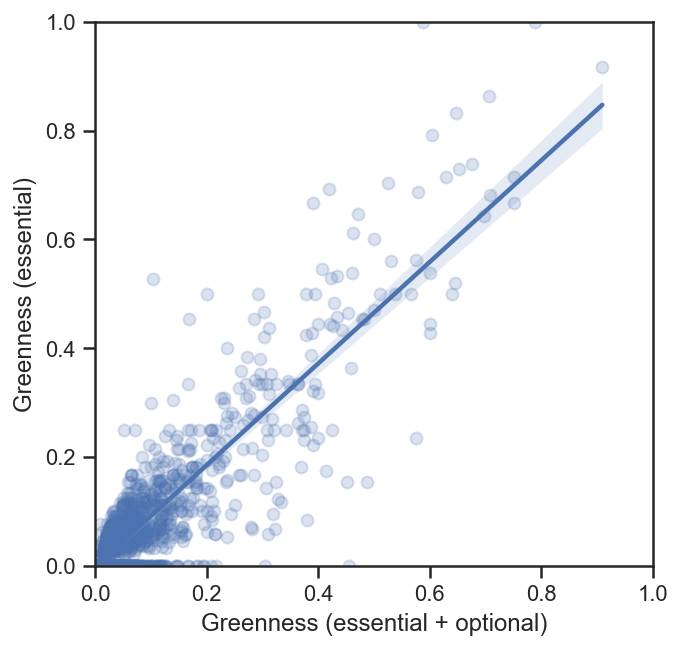

In [107]:
x = gbn_all.share_green_esco
y = gbn_core.share_green_esco

ax = sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 0.2}
)

ax.set_xlabel("Greenness (essential + optional)")
ax.set_ylabel("Greenness (essential)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

pg.corr(x, y)

,n,r,CI95%,p-val,BF10,power
pearson,3007,0.875473,"[0.87, 0.88]",0.0,inf,1.0


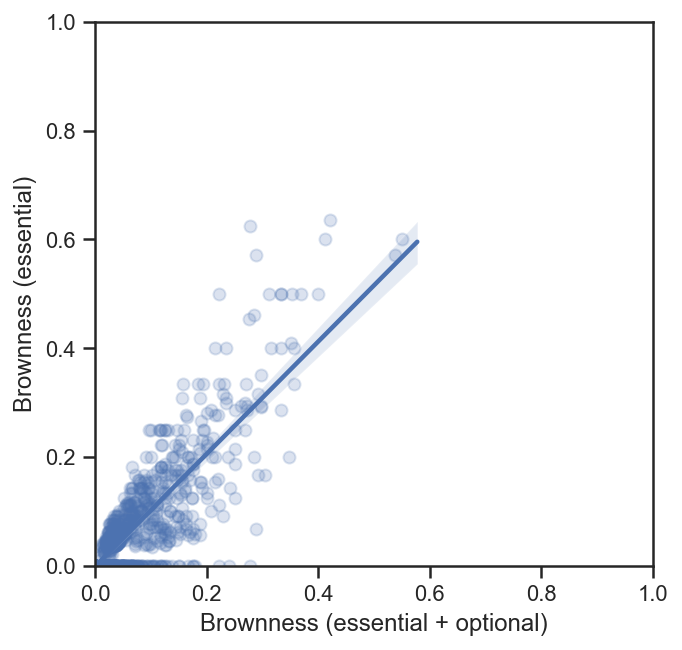

In [101]:
x = gbn_all.share_brown_esco
y = gbn_core.share_brown_esco

ax = sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha": 0.2},
    truncate=False
)

ax.set_xlabel("Brownness (essential + optional)")
ax.set_ylabel("Brownness (essential)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

pg.corr(x, y)

#### Comparison of occupational greenness/brownness between using all skills and essential skills only

In [108]:
of.combine_occupation_metadata()

INFO:src.data.framework:Creating occupation-skills matrix.
INFO:src.data.framework:Creating occupation-skills matrix.


T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\src\data\framework.py:810: RuntimeWarning: invalid value encountered in true_divide
  print(n_gbn_specific_skills, n_total_specific_skills)


,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco,gbn_classification_esco,n_total_specific_skills_ess,n_green_specific_skills_esco_ess,share_green_esco_ess,n_brown_specific_skills_esco_ess,share_brown_esco_ess,n_neutral_specific_skills_esco_ess,share_neutral_esco_ess,gbn_classification_esco_ess,onet_code,title_gtp,occupation_type,n_new_green_tasks_gtp,n_existing_green_tasks_gtp,n_non_green_tasks_gtp,share_green_gtp,title_vona2018,share_green_vona2018,total_spec_tasks_vona2018,green_spec_tasks_vona2018,id,concept_uri,preferred_label,onet_occupation,is_brown_onet,is_green_onet,is_neutral_onet,gbn_classification_onet
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",8,0,0.000000,0,0.0,8,1.000000,neutral,8,0,0.000000,0,0.0,8,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
1,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",39,0,0.000000,0,0.0,39,1.000000,neutral,20,0,0.000000,0,0.0,20,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
2,Occupation,http://data.europa.eu/esco/occupation/2f372afe...,2654,performance lighting director,television lighting supervisor\nTV lighting su...,NaN,released,2016-07-05T13:46:52Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Performance lighting directors determine what ...,2654.1.4,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",38,2,0.052632,0,0.0,36,0.947368,neutral,18,1,0.055556,0,0.0,17,0.944444,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
3,Occupation,http://data.europa.eu/esco/occupation/30b25ee4...,2654,animation director,animation process director\ncartoon animation ...,NaN,released,2021-03-31T15:31:28.501Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Animation directors supervise and recruit mult...,2654.1.1,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",41,0,0.000000,0,0.0,41,1.000000,neutral,15,0,0.000000,0,0.0,15,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
4,Occupation,http://data.europa.eu/esco/occupation/3b6bea7d...,2654,video and motion picture producer,video & motion picture producer\nmovie produce...,NaN,released,2017-01-17T13:58:37Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture producers supervise t...,2

Green

In [113]:
of.occupation_metadata.sort_values("share_green_esco", ascending=False).head(20)

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco,gbn_classification_esco,n_total_specific_skills_ess,n_green_specific_skills_esco_ess,share_green_esco_ess,n_brown_specific_skills_esco_ess,share_brown_esco_ess,n_neutral_specific_skills_esco_ess,share_neutral_esco_ess,gbn_classification_esco_ess,onet_code,title_gtp,occupation_type,n_new_green_tasks_gtp,n_existing_green_tasks_gtp,n_non_green_tasks_gtp,share_green_gtp,title_vona2018,share_green_vona2018,total_spec_tasks_vona2018,green_spec_tasks_vona2018,id,concept_uri,preferred_label,onet_occupation,is_brown_onet,is_green_onet,is_neutral_onet,gbn_classification_onet
1689,Occupation,http://data.europa.eu/esco/occupation/c7f5cab7...,3112,energy assessor,energy performance certificate assessor\nenerg...,NaN,released,2016-07-05T16:04:20Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Energy assessors determine the energy performa...,3112.1.5,3112,3,31,311,Technicians and associate professionals,Science and engineering associate professionals,Physical and engineering science technicians,Civil engineering technicians,22,20,0.909091,0,0.000000,2,0.090909,green,12,11,0.916667,0,0.000000,1,0.083333,green,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
770,Occupation,http://data.europa.eu/esco/occupation/fab474ea...,2133,natural resources consultant,resources consultant\nnatural resources expert...,NaN,released,2017-01-17T14:27:38Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Natural resources consultant provide advice on...,2133.8,2133,2,21,213,Professionals,Science and engineering professionals,Life science professionals,Environmental protection professionals,33,26,0.787879,0,0.000000,7,0.212121,green,12,12,1.000000,0,0.000000,0,0.000000,green,19-2041.03,Industrial Ecologists,New Green N&E,38.0,0.0,0.0,1.000000,NaN,NaN,NaN,NaN,2880.0,http://data.europa.eu/esco/occupation/fab474ea...,natural resources consultant,industrial ecologists,False,True,False,green
1674,Occupation,http://data.europa.eu/esco/occupation/23a61ff1...,3112,energy conservation officer,energy information officer\nenergy management ...,NaN,released,2020-12-09T08:38:48.962Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Energy conservation officers promote the conse...,3112.6,3112,3,31,311,Technicians and associate professionals,Science and engineering associate professionals,Physical and engineering science technicians,Civil engineering technicians,16,12,0.750000,0,0.000000,4,0.250000,green,14,10,0.714286,0,0.000000,4,0.285714,green,47-4099.03,Weatherization Installers and Technicians,New Green N&E,18.0,0.0,0.0,1.000000,Weatherization Installers and Technicians,1.000000,18.0,18.0,430.0,http://data.europa.eu/esco/occupation/23a61ff1...,energy conservation officer,weatherization installers and technicians,False,True,False,green
254,Occupation,http://data.europa.eu/esco/occupation/b5d2db88...,2422,environmental policy officer,environmental officer\nenvironmental policy ad...,NaN,released,2021-12-08T20:02:08.2Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,"Environmental policy officers research, analys...",2422.12.5,2422,2,24,242,Professionals,Business and administration professionals,Administration professionals,Policy administration professionals,36,27,0.750000,0,0.000000,9,0.250000,green,18,12,0.666667,0,0.000000,6,0.333333,green,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [114]:
of.occupation_metadata.sort_values("share_green_esco_ess", ascending=False).head(20)

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco,gbn_classification_esco,n_total_specific_skills_ess,n_green_specific_skills_esco_ess,share_green_esco_ess,n_brown_specific_skills_esco_ess,share_brown_esco_ess,n_neutral_specific_skills_esco_ess,share_neutral_esco_ess,gbn_classification_esco_ess,onet_code,title_gtp,occupation_type,n_new_green_tasks_gtp,n_existing_green_tasks_gtp,n_non_green_tasks_gtp,share_green_gtp,title_vona2018,share_green_vona2018,total_spec_tasks_vona2018,green_spec_tasks_vona2018,id,concept_uri,preferred_label,onet_occupation,is_brown_onet,is_green_onet,is_neutral_onet,gbn_classification_onet
762,Occupation,http://data.europa.eu/esco/occupation/59883630...,2133,environmental programme coordinator,environmental health officer\nsustainability c...,NaN,released,2020-12-08T12:24:18.382Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Environmental programme coordinators develop p...,2133.6,2133,2,21,213,Professionals,Science and engineering professionals,Life science professionals,Environmental protection professionals,34,20,0.588235,0,0.000000,14,0.411765,green,14,14,1.000000,0,0.0,0,0.000000,green,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
770,Occupation,http://data.europa.eu/esco/occupation/fab474ea...,2133,natural resources consultant,resources consultant\nnatural resources expert...,NaN,released,2017-01-17T14:27:38Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Natural resources consultant provide advice on...,2133.8,2133,2,21,213,Professionals,Science and engineering professionals,Life science professionals,Environmental protection professionals,33,26,0.787879,0,0.000000,7,0.212121,green,12,12,1.000000,0,0.0,0,0.000000,green,19-2041.03,Industrial Ecologists,New Green N&E,38.0,0.0,0.0,1.000000,NaN,NaN,NaN,NaN,2880.0,http://data.europa.eu/esco/occupation/fab474ea...,natural resources consultant,industrial ecologists,False,True,False,green
1689,Occupation,http://data.europa.eu/esco/occupation/c7f5cab7...,3112,energy assessor,energy performance certificate assessor\nenerg...,NaN,released,2016-07-05T16:04:20Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Energy assessors determine the energy performa...,3112.1.5,3112,3,31,311,Technicians and associate professionals,Science and engineering associate professionals,Physical and engineering science technicians,Civil engineering technicians,22,20,0.909091,0,0.000000,2,0.090909,green,12,11,0.916667,0,0.0,1,0.083333,green,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
658,Occupation,http://data.europa.eu/esco/occupation/a7358961...,2143,environmental expert,environmental scientist\nsoil scientist\nenvir...,NaN,released,2020-12-08T12:24:26.113Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Environmental experts search for technological...,2143.2,2143,2,21,214,Professionals,Science and engineering professionals,Engineering professionals (excluding electrote...,Environmental engineers,34,24,0.705882,0,0.000000,10,0.294118,green,22,19,0.863636,0,0.0,3,0.136364,green,17-2081.00,Environmental Engineers,Green Enhanced Skills,3.0,25.0,0.0,1.000000,Environmental Engineers,1.000000,28.0,28.0,1976.0,http://data.europa.eu/esco/occupation/a7358961...,environmental expert,environmental engineers,False,True,False,green
727,Occupation,http://data.europa.eu/esco/occupation/92efb42f...,2

Brown

In [115]:
of.occupation_metadata.sort_values("share_brown_esco_ess", ascending=False).head(20)

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco,gbn_classification_esco,n_total_specific_skills_ess,n_green_specific_skills_esco_ess,share_green_esco_ess,n_brown_specific_skills_esco_ess,share_brown_esco_ess,n_neutral_specific_skills_esco_ess,share_neutral_esco_ess,gbn_classification_esco_ess,onet_code,title_gtp,occupation_type,n_new_green_tasks_gtp,n_existing_green_tasks_gtp,n_non_green_tasks_gtp,share_green_gtp,title_vona2018,share_green_vona2018,total_spec_tasks_vona2018,green_spec_tasks_vona2018,id,concept_uri,preferred_label,onet_occupation,is_brown_onet,is_green_onet,is_neutral_onet,gbn_classification_onet
1006,Occupation,http://data.europa.eu/esco/occupation/8fdce434...,8114,electrolytic cell maker,cover maker\ncell maker\nconcrete electrolytic...,NaN,released,2021-03-29T15:11:04.319Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,"Electrolytic cell makers create, finish and te...",8114.4,8114,8,81,811,Plant and machine operators and assemblers,Stationary plant and machine operators,Mining and mineral processing plant operators,"Cement, stone and other mineral products machi...",19,0,0.000000,8,0.421053,11,0.578947,neutral,11,0,0.000000,7,0.636364,4,0.363636,brown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
932,Occupation,http://data.europa.eu/esco/occupation/39e06c20...,8131,soap maker,soapmaker\nsoap boiler\nsoap factory operator\...,NaN,released,2016-07-05T16:56:48Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Soap makers operate equipments and mixers that...,8131.19,8131,8,81,813,Plant and machine operators and assemblers,Stationary plant and machine operators,Chemical and photographic products plant and m...,Chemical products plant and machine operators,18,2,0.111111,5,0.277778,11,0.611111,neutral,8,0,0.000000,5,0.625000,3,0.375000,brown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,brown
1005,Occupation,http://data.europa.eu/esco/occupation/8d3fd879...,8114,precast moulder,hand tile-moulder\npre-cast moulder\nprecast m...,NaN,released,2016-07-05T17:01:55Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Precast moulders handcast decorative and struc...,8114.5,8114,8,81,811,Plant and machine operators and assemblers,Stationary plant and machine operators,Mining and mineral processing plant operators,"Cement, stone and other mineral products machi...",20,0,0.000000,11,0.550000,9,0.450000,brown,10,0,0.000000,6,0.600000,4,0.400000,brown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
1061,Occupation,http://data.europa.eu/esco/occupation/8edc768c...,8141,V-belt builder,V-belt forming machine operative\nv-belt build...,NaN,released,2016-10-20T17:25:05Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,V-belt builders form V-belts out of calendered...,8141.1.9,8141,8,81,814,Plant and machine operators and assemblers,Stationary plant and machine operators,"Rubber, plastic and paper products machine ope...",Rubber products machine operators,17,0,0.000000,7,0.411765,10,0.588235,neutral,10,0,0.000000,6,0.600000,4,0.400000,brown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,brown
947,Occupation,http://data.europa.eu/esco/occupation/ee37a4a5...,8131,tracer powder blender,flammable chemical mixer\ntracer-powder blende...,NaN,released,2016-10-20T14:58:06Z,http://data.europa.eu/